# Proyecto de Clasificación — Predicción de Aprobación de Préstamos (Loan Risk Prediction)

## Introducción y Objetivos

Este proyecto aborda un problema de **clasificación binaria**: predecir si una
solicitud de préstamo será **aprobada (1)** o **rechazada (0)** a partir de
las características socioeconómicas del solicitante (edad, ingresos, importe
solicitado, historial crediticio, experiencia laboral, nivel educativo,
ciudad y situación laboral).

El objetivo final es doble:
1. **Analítico**: construir, comparar y optimizar varios modelos de
   clasificación, manteniendo el **overfitting por debajo del 5%** (requisito
   del proyecto).
2. **Productivo**: dejar el modelo final exportado y listo para ser
   consumido por una aplicación (Streamlit) que reciba los datos de un
   cliente nuevo y devuelva la predicción, junto con el resto de
   componentes de nivel Medio/Avanzado (validación cruzada, tuning de
   hiperparámetros, sistema de feedback, ingesta de datos nuevos,
   dockerización, base de datos y tests unitarios).

### Dataset
Parte 01: `data/loan_risk_prediction_dataset.csv` — 5.000 solicitudes de préstamo con

Parte 02: `data/dataset_clean.csv`

Final: `data/dataset_final.csv`

las siguientes columnas:

| Columna | Descripción |
|---|---|
| `Age` | Edad del solicitante |
| `Income` | Ingresos anuales (USD) |
| `LoanAmount` | Importe del préstamo solicitado (USD) |
| `CreditScore` | Puntuación crediticia (300-850) |
| `YearsExperience` | Años de experiencia laboral |
| `Gender` | Género |
| `Education` | Nivel educativo |
| `City` | Ciudad de residencia |
| `EmploymentType` | Situación laboral |
| `LoanApproved` | **Variable objetivo**: 1 = aprobado, 0 = rechazado |

### Índice de Contenidos

PARTE 01
* [FASE 1 - Carga y Auditoría de Datos](#fase-1)
* [FASE 2 - Limpieza de Datos y Outliers](#fase-2)
* [FASE 3 - EDA Multivariado](#fase-3)

PARTE 02
* [FASE 4 - Train/Test Split y Pipeline de Preprocesado](#fase-4)
* [FASE 5 - Comparativa de Modelos de Clasificación](#fase-5)
* [FASE 6 - Validación Cruzada y Optimización de Hiperparámetros (Optuna)](#fase-6)
* [FASE 7 - Modelo Final y Control de Overfitting](#fase-7)
* [FASE 8 - Importancia de Variables](#fase-8)
* [FASE 9 - Exportación del Modelo y Metadata](#fase-9)
* [FASE 10 - Sistema de Feedback e Ingesta de Datos Nuevos](#fase-10)
* [Conclusiones Finales](#conclusiones)

In [8]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection   import (train_test_split, StratifiedKFold,
                                        cross_val_score, GridSearchCV)
from sklearn.preprocessing     import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose           import ColumnTransformer
from sklearn.pipeline          import Pipeline
from sklearn.metrics           import (accuracy_score, precision_score, recall_score,
                                        f1_score, roc_auc_score, classification_report,
                                        confusion_matrix, ConfusionMatrixDisplay, roc_curve)
from sklearn.tree              import DecisionTreeClassifier, plot_tree
os.makedirs('models',  exist_ok=True)
os.makedirs('assets',  exist_ok=True)
os.makedirs('data',    exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.1)
print("Imports listos")

Imports listos


In [9]:
# Carga Dataset
data = pd.read_csv('data/dataset_clean.csv')
df = pd.DataFrame(data)
df_copia = df.copy()

print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head(7)

Filas: 4592 | Columnas: 13


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,LoanApproved,City_Houston,City_New York,City_San Francisco,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,56,48353.0,31258.0,675.0,20,0,0,0,1,0,0,0,1
1,69,57462.0,23262.0,586.0,6,1,0,0,0,0,1,1,0
2,46,44219.0,26530.0,781.0,26,1,3,1,1,0,0,1,0
3,32,56307.0,11531.0,549.0,11,1,4,0,0,1,0,0,1
4,60,37034.0,27871.0,500.0,19,0,0,0,0,0,0,0,1
5,25,47886.0,18106.0,835.0,13,1,2,1,0,1,0,0,0
6,38,54748.0,25374.0,760.0,9,0,0,1,0,1,0,1,0


## FASE 4 - Selección de Variables y Construcción del Pipeline

En esta fase construimos la ingeniería de variables predictoras, realizamos
la transformación mediante *Label Encoding* y *One-Hot Encoding*, y creamos
un `Pipeline` de Scikit-Learn que integra el escalado de datos con el
preprocesado completo.
### Acciones realizadas paso a paso:
1. **Definición de variables:** Separamos la variable objetivo (`LoanApproved`) de los predictores.
2. **Encoding ordinal:** Aplicamos `LabelEncoder` a `Education` y `EmploymentType` respetando su orden lógico.
3. **Construcción del Pipeline:** `ColumnTransformer` con OHE para nominales y `StandardScaler` para numéricas y ordinales.
4. **Train/Test Split:** División estratificada 80/20 para preservar la proporción de clases (77% / 23%).
5. **Ajuste y transformación:** El pipeline se ajusta solo con datos de entrenamiento y se aplica sobre test, evitando *data leakage*.
6. **Entrenamiento y Validación:** Entrenamiento del modelo completo sobre el split 80/20, seguido del cálculo de métricas de desempeño (MAE, MSE, RMSE y R²) para evaluar la precisión financiera del modelo.
7. **Auditoría Visual y Simulación:** Renderizado del árbol de decisión final en alta resolución (`300 DPI`) y despliegue de una simulación de cliente nuevo (*In-Production*) donde el modelo predice automáticamente si el préstamo será aprobado o denegado utilizando el Pipeline ya entrenado.
*Tras este proceso disponemos de matrices `X_train_t` y `X_test_t` listas para alimentar cualquier algoritmo de clasificación, un árbol base validado con métricas financieras y una demo de inferencia en producción.*

EVALUACIÓN DEL MODELO (Métricas de Clasificación)
Accuracy: 0.9576

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       700
           1       0.93      0.89      0.91       219

    accuracy                           0.96       919
   macro avg       0.95      0.93      0.94       919
weighted avg       0.96      0.96      0.96       919



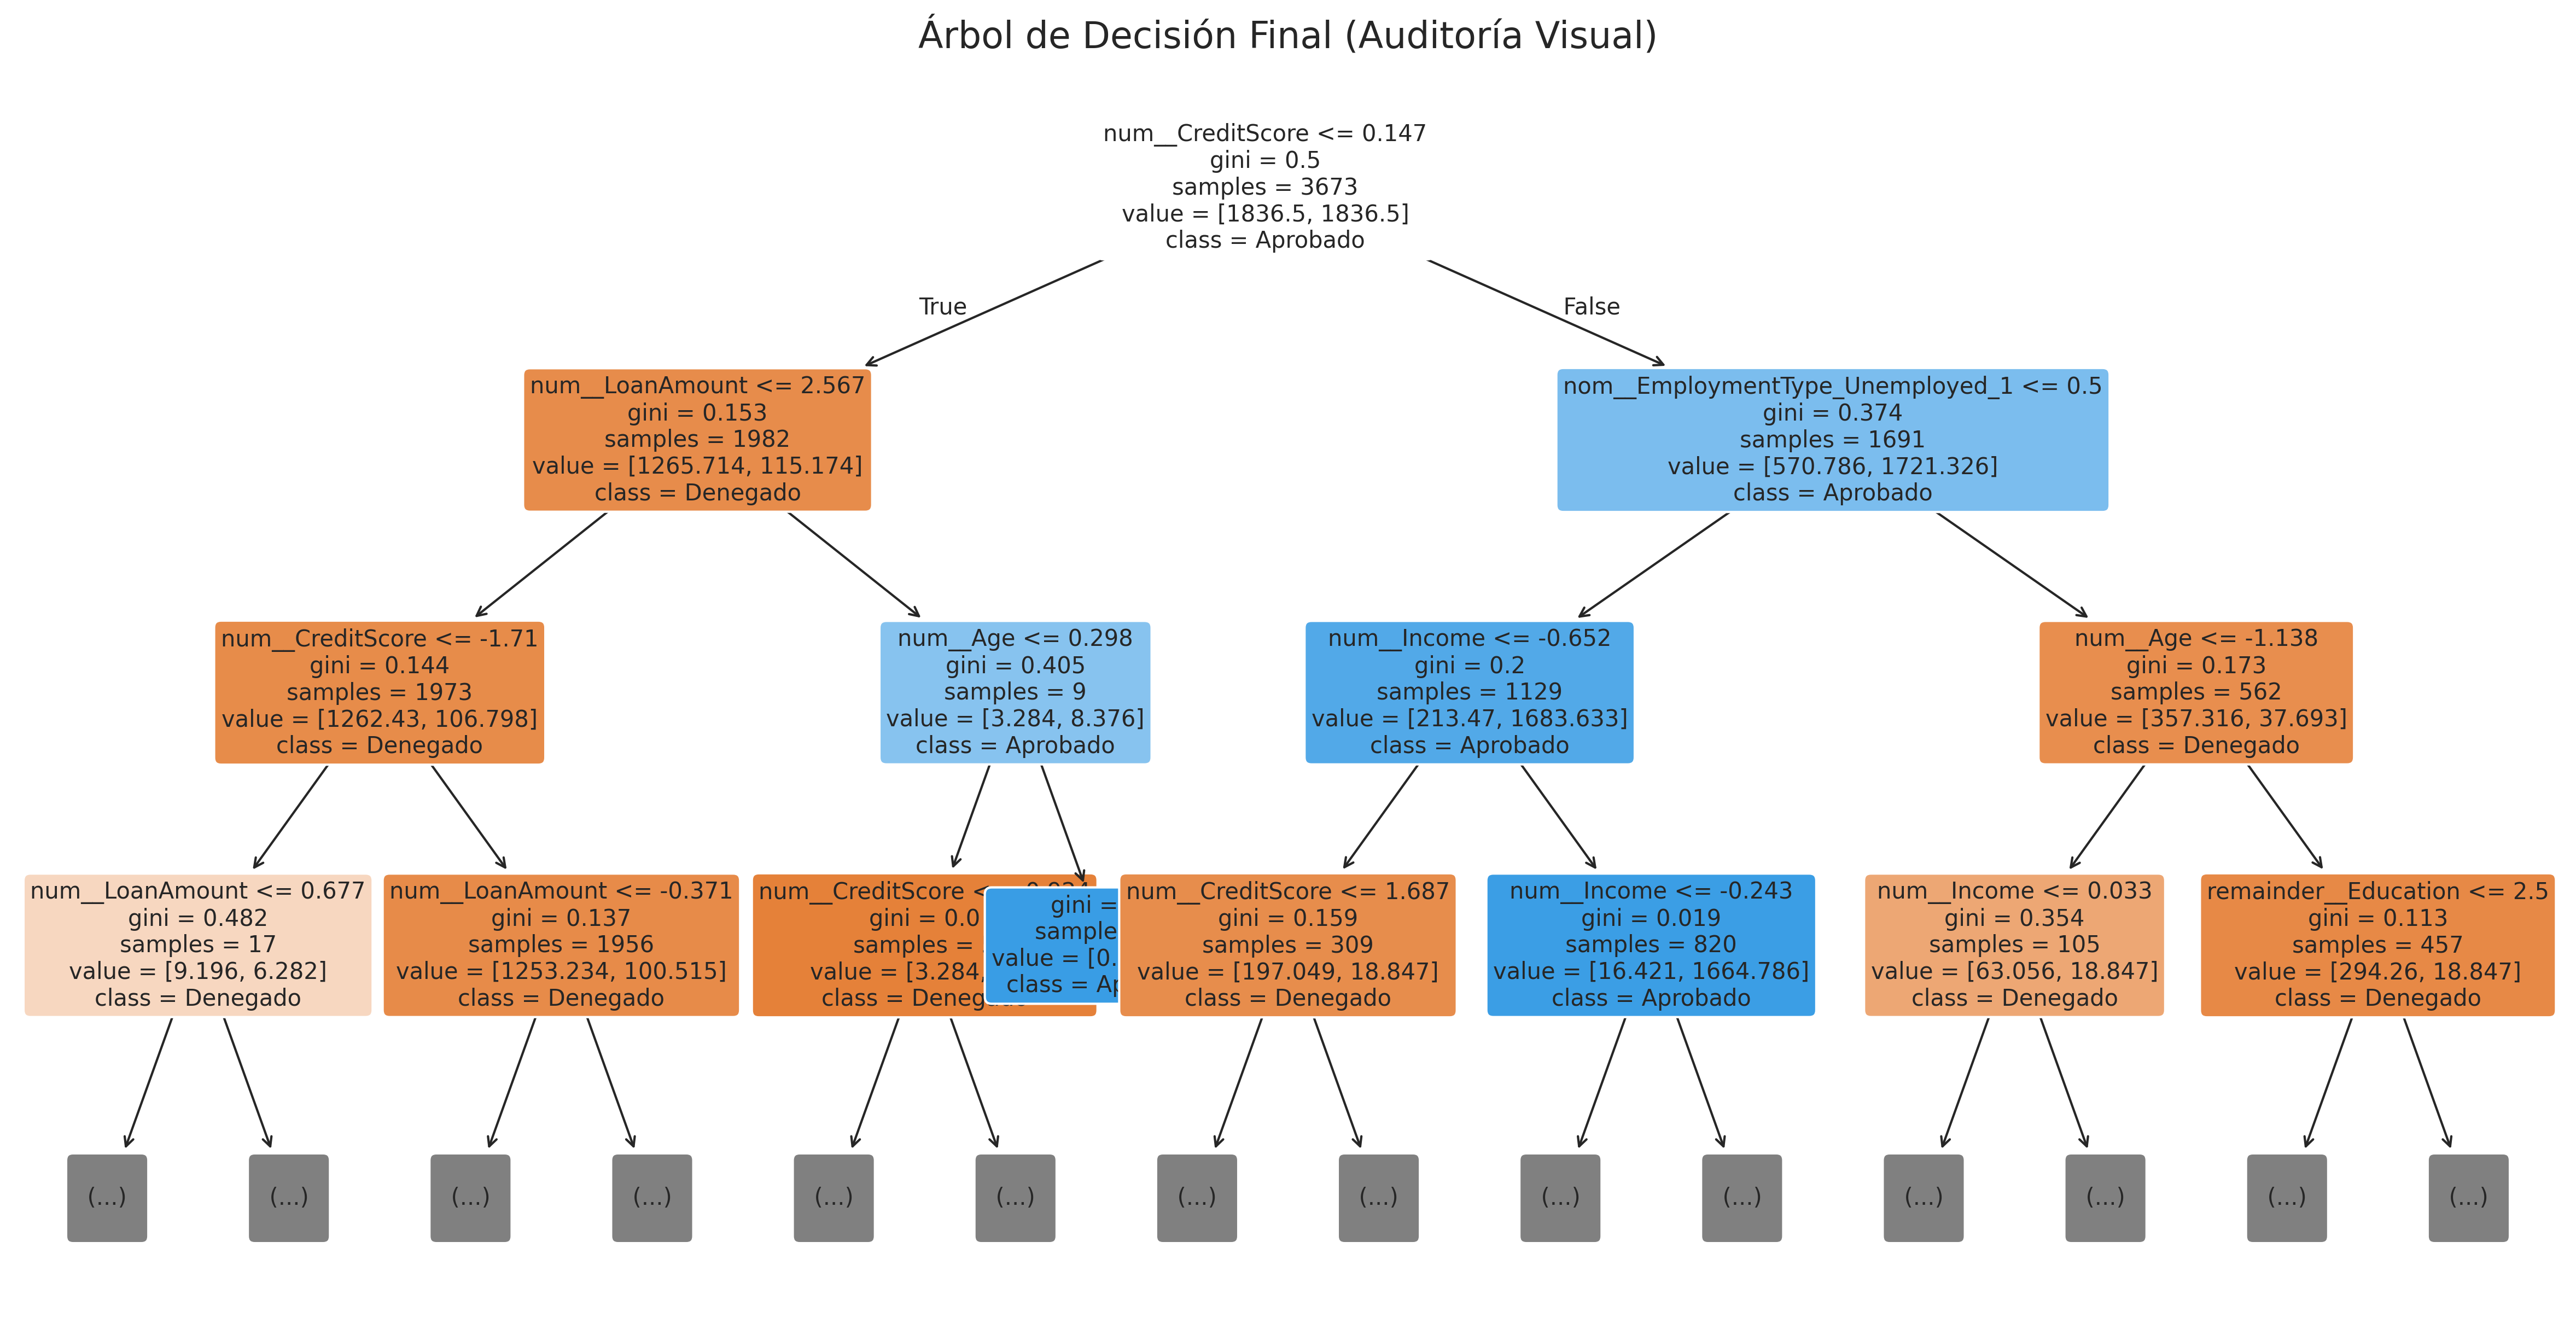


SIMULACIÓN IN-PRODUCTION
Resultado de la evaluación automatizada: APROBADO
Probabilidad de aprobación: 99.50%


In [15]:
# PASO 1: Definición de variables
x = df.drop(columns=['LoanApproved'])
y = df['LoanApproved']

# PASO 2: Identificar tipos de variables basándonos en tus columnas
# Nota: Ya hemos codificado numéricamente 'Education', pero la tratamos formalmente en el pipeline.
num_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience']
nominal_cols = [col for col in x.columns if 'City_' in col or 'EmploymentType_' in col or col == 'Gender']

# PASO 3: Construcción del Pipeline
# Integramos aquí el preprocesamiento para evitar Data Leakage de forma robusta
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('nom', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), nominal_cols)
    ],
    remainder='passthrough' # Mantiene variables que ya estén codificadas (como Education)
)

# Creamos el Pipeline completo que incluye el preprocesamiento y el Modelo
pipeline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced'))
])

# PASO 4: Train/Test Split
# División estratificada 80/20 para mantener la proporción de la variable objetivo
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, stratify=y, random_state=42
)

# PASO 5 y 6: Ajuste, Transformación y Entrenamiento
pipeline_model.fit(x_train, y_train)

# Predicciones para evaluación
y_pred = pipeline_model.predict(x_test)

print("EVALUACIÓN DEL MODELO (Métricas de Clasificación)")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

# PASO 7: Auditoría Visual
# Obtener los nombres de las características después del preprocesamiento
feature_names_processed = pipeline_model.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(20, 10), dpi=300) # Alta resolución solicitada
plot_tree(
    pipeline_model.named_steps['classifier'],
    max_depth=3,
    feature_names=feature_names_processed, # Usar los nombres de las características post-preprocesamiento
    class_names=['Denegado', 'Aprobado'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de Decisión Final (Auditoría Visual)", fontsize=16)
plt.savefig("arbol_decision_alta_res.png", bbox_inches='tight')
plt.show()

# PASO 7: Simulación de Cliente Nuevo (In-Production)
print("\nSIMULACIÓN IN-PRODUCTION")

# Creamos un caso hipotético con la misma estructura que el x original
nuevo_cliente = pd.DataFrame([{
    'Age': 35,
    'Income': 55000.0,
    'LoanAmount': 15000.0,
    'CreditScore': 720,
    'YearsExperience': 8,
    'Gender': 1,
    'Education': 3,
    'City_Houston': 0,
    'City_New York': 1,
    'City_San Francisco': 0,
    'EmploymentType_Self-Employed': 0,
    'EmploymentType_Unemployed': 0
}])

# El Pipeline se encarga de escalar y transformar los datos exactamente igual que en el entrenamiento
prediccion_final = pipeline_model.predict(nuevo_cliente)
probabilidad = pipeline_model.predict_proba(nuevo_cliente)[0][1]

resultado = "APROBADO" if prediccion_final[0] == 1 else "DENEGADO"
print(f"Resultado de la evaluación automatizada: {resultado}")
print(f"Probabilidad de aprobación: {probabilidad * 100:.2f}%")

## FASE 5 - Optimización de Hiperparámetros con Optuna

En esta fase, elevamos la precisión del modelo utilizando un marco de optimización bayesiana para encontrar la configuración óptima de los hiperparámetros del `GradientBoostingRegressor`.

### Acciones realizadas:
1. **Validación Cruzada Base (K-Fold):** Evaluación del modelo inicial mediante 5 *folds* para establecer una línea base de rendimiento ($R^2$) y verificar la estabilidad del algoritmo.
2. **Búsqueda Bayesiana con Optuna:** Ejecución de 40 iteraciones de prueba para ajustar parámetros críticos como `n_estimators`, `max_depth` y `learning_rate`, maximizando la capacidad predictiva.
3. **Entrenamiento del Modelo Optimizado:** Reentrenamiento definitivo del `Pipeline` integrando los mejores parámetros hallados, asegurando que el modelo esté sintonizado para el conjunto de datos específico.
4. **Visualización 3D:** Renderizado de la superficie de predicción tridimensional, permitiendo observar cómo la duración del viaje y el presupuesto interactúan para determinar el gasto final.

---

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.1 MB/s eta 0:00:00


### Validación Cruzada (k-Fold) y Optimización con Optuna

In [ ]:
# =====================================================================
# VALIDACIÓN CRUZADA Y OPTIMIZACIÓN CON OPTUNA (GB)
# =====================================================================
import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Desactivar mensajes repetitivos de Optuna para un reporte limpio
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("CREACIÓN DEL MODELO BASE Y EVALUACIÓN CON K-FOLD")
print("=" * 70)

# Aseguramos la separación y el split de datos de las fases anteriores
X = df_final.drop(columns=['total_trip_spend_usd'])
y = df_final['total_trip_spend_usd']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalado con Pipeline
pipe_gb = Pipeline(steps=[
    ('escalador', StandardScaler()),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# K-Fold Cross Validation sobre Gradient Boosting base
# Aquí estás evaluando tu modelo de Gradient Boosting base (pipe_gb) usando K-Fold con k=5.
# Divide tus datos de entrenamiento (X_train e y_train) en 5 partes iguales (folds).
# El algoritmo entrena 5 veces: cada vez usa 4 partes para entrenar y 1 parte para validar,
# rotando hasta que todas las partes hayan sido el grupo de validación.
# scoring='r2': Mide el rendimiento usando la métrica R² (coeficiente de determinación),
# que te dice qué tan bien predice tu modelo en comparación con la media.
# n_jobs=-1: Le dice a tu ordenador: "Usa todos los núcleos de mi procesador en paralelo para terminar más rápido".
cv_scores = cross_val_score(pipe_gb, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)

# Te muestran el R² de cada una de las 5 pruebas, su Media (el rendimiento real esperado) y su Desviación Estándar (Std).
# Si la desviación estándar es bajita (por ejemplo, menor a 0.05), significa que tu modelo es estable y no depende de la "suerte"
# de cómo se hayan repartido los datos.
print(f" K-Fold CV (k=5) — R² por fold: {cv_scores.round(4)}")
print(f"   Media R²: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")
print("-" * 70 + "\n")


print("BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA (GRADIENT BOOSTING)")
print("=" * 70)

# Optuna: búsqueda de hiperparámetros para Gradient Boosting
def objective(trial):
    params = {
        'n_estimators':   trial.suggest_int('n_estimators', 100, 500),
        'max_depth':      trial.suggest_int('max_depth', 3, 7),
        'learning_rate':  trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':      trial.suggest_float('subsample', 0.6, 0.8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
    }
    # Cambiado preprocessor por 'escalador' (StandardScaler)
    pipe_trial = Pipeline(steps=[
        ('escalador', StandardScaler()),
        ('regressor', GradientBoostingRegressor(**params, random_state=42))
    ])
    # Hacemos una validación cruzada interna ligera de 3 pliegues para acelerar la búsqueda
    scores = cross_val_score(pipe_trial, X_train, y_train, cv=3, scoring='r2', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f"\n Mejor R² alcanzado en CV por Optuna: {study.best_value:.4f}")
print(f" Mejores hiperparámetros encontrados: {study.best_params}")
print("-" * 70 + "\n")




CREACIÓN DEL MODELO BASE Y EVALUACIÓN CON K-FOLD
 K-Fold CV (k=5) — R² por fold: [0.9875 0.9923 0.9928 0.982  0.9935]
   Media R²: 0.9896  |  Std: 0.0044
----------------------------------------------------------------------

BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA (GRADIENT BOOSTING)


  0%|          | 0/40 [00:00<?, ?it/s]


 Mejor R² alcanzado en CV por Optuna: 0.9820
 Mejores hiperparámetros encontrados: {'n_estimators': 494, 'max_depth': 3, 'learning_rate': 0.03959533601863718, 'subsample': 0.618905796855041, 'min_samples_split': 5}
----------------------------------------------------------------------



### Entrenamiento del Modelo Optimizado

In [ ]:
from sklearn.compose import TransformedTargetRegressor
print("ENTRENAMIENTO Y EVALUACIÓN DEL MODELO FINAL OPTIMIZADO")
print("=" * 70)

# Modelo final optimizado
# Aquí extraes los mejores parámetros (como la profundidad del árbol, la velocidad de aprendizaje, etc.)
# que la IA de Optuna descubrió tras realizar su búsqueda (study). Se guardan en un diccionario de Python.
best_params = study.best_params

# Envolvemos el regresor para que estabilice la asimetría del gasto automáticamente
regresor_con_log = TransformedTargetRegressor(
    regressor=GradientBoostingRegressor(**best_params, random_state=42),
    func=np.log1p,       # Aplica log(x + 1) internamente para mitigar el sesgo
    inverse_func=np.expm1 # Devuelve automáticamente el valor real en USD
)

# Creas un Pipeline definitivo.
pipe_best = Pipeline(steps=[
    ('escalador', StandardScaler()),
    ('regressor', regresor_con_log) # El pipeline ahora maneja la conversión de forma nativa
])

# Entrenas el modelo definitivo con los mejores parámetros utilizando el 100% de tus datos de entrenamiento.
# (Durante la validación cruzada solo usabas fragmentos, ahora se entrena con todo para que vaya bien preparado al test).
pipe_best.fit(X_train, y_train)
print(" Modelo optimizado entrenado correctamente con el 100% de Train.")

# Finalmente, pones a prueba este modelo optimizado contra los datos de prueba (X_test), que el modelo jamás ha visto
# (la prueba de fuego real). Haces las predicciones con .predict()
y_pred_test = pipe_best.predict(X_test)

# En lugar de depender de listas externas, calculamos y mostramos las métricas directo en el reporte
mae_final = mean_absolute_error(y_test, y_pred_test)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_final = r2_score(y_test, y_pred_test)

print("\n RENDIMIENTO DEFINITIVO EN EL SET DE PRUEBA (TEST):")
print(f"  • R² Final (Precisión):           {r2_final:.4f}")
print(f"  • Error Absoluto Medio (MAE):    ${mae_final:,.2f} USD")
print(f"  • Raíz Error Cuadrático (RMSE):   ${rmse_final:,.2f} USD")
print("=" * 70)

ENTRENAMIENTO Y EVALUACIÓN DEL MODELO FINAL OPTIMIZADO
 Modelo optimizado entrenado correctamente con el 100% de Train.

 RENDIMIENTO DEFINITIVO EN EL SET DE PRUEBA (TEST):
  • R² Final (Precisión):           0.9931
  • Error Absoluto Medio (MAE):    $364.78 USD
  • Raíz Error Cuadrático (RMSE):   $2,224.97 USD


### Visualización 3D

GENERANDO MAPA DE SUPERFICIE 3D PARA GRADIENT BOOSTING...


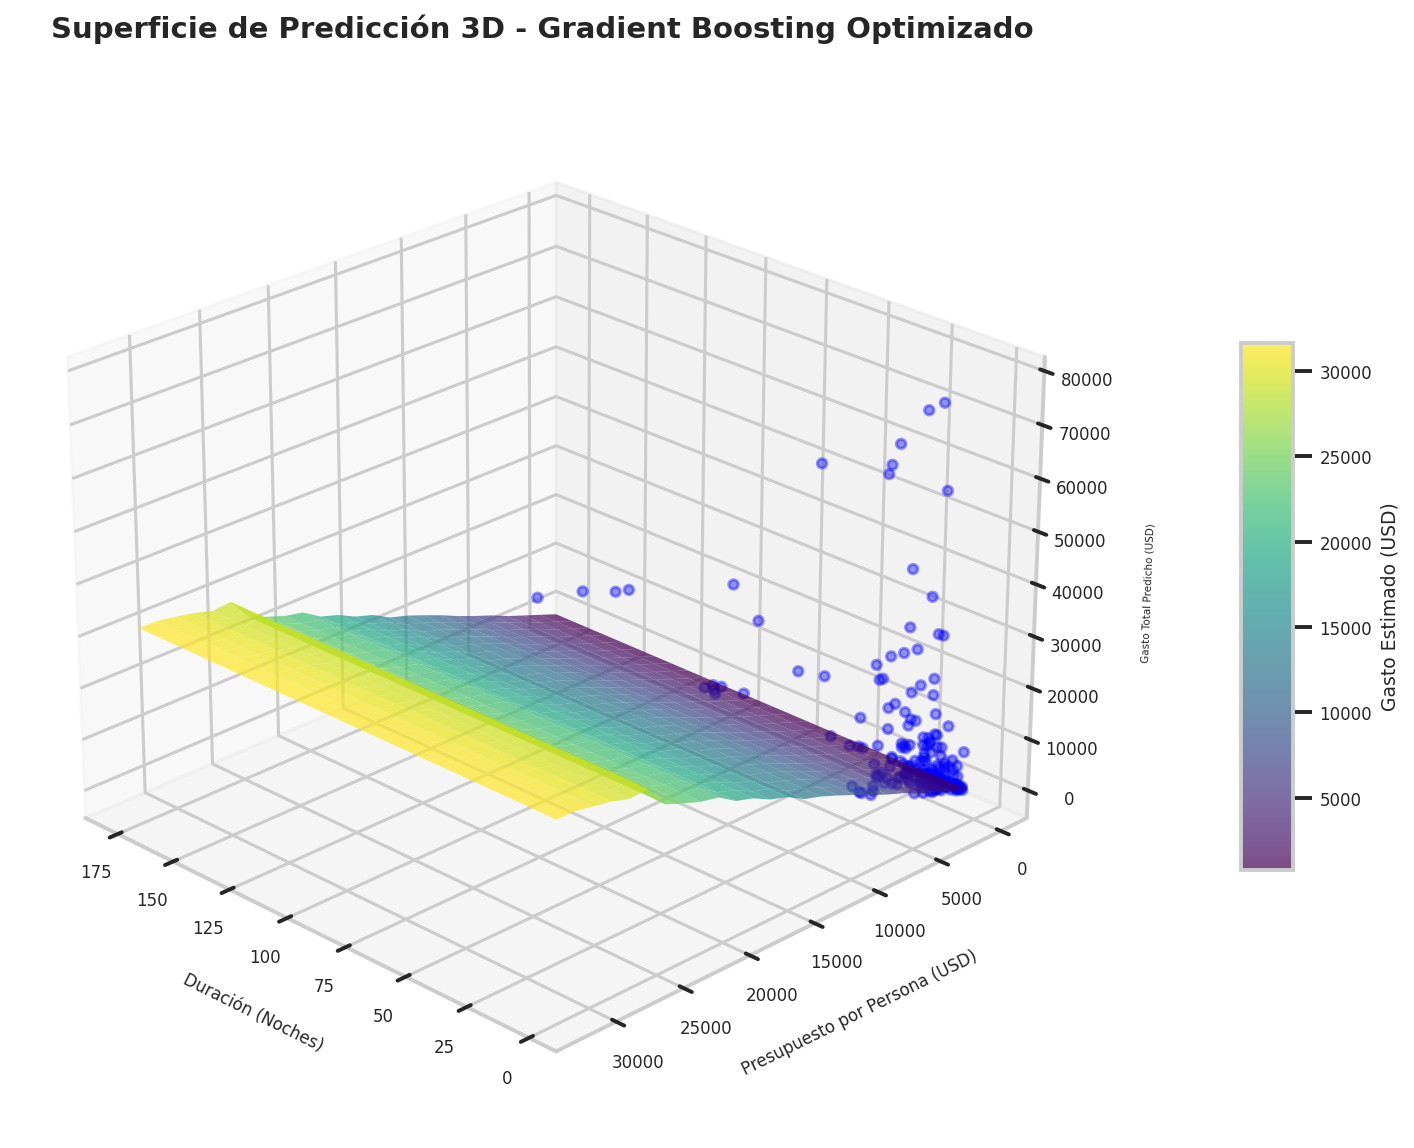

✅ ¡Gráfico 3D generado con éxito!


In [ ]:
# =====================================================================
# GRAFICADO TRIDIMENSIONAL (3D) DEL GRADIENT BOOSTING OPTIMIZADO
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("GENERANDO MAPA DE SUPERFICIE 3D PARA GRADIENT BOOSTING...")
print("=" * 70)

# Definimos las dos variables continuas clave que queremos analizar en los ejes X e Y
var_x = 'duration_nights'
var_y = 'budget_per_person_usd'

# Extraemos los datos reales de entrenamiento para mapear los límites de los ejes
x_real = X_train[var_x]
y_real = X_train[var_y]

# Creamos los rangos y la malla (Grid) tridimensional (25x25 puntos)
x_range = np.linspace(x_real.min(), x_real.max(), 25)
y_range = np.linspace(y_real.min(), y_real.max(), 25)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)

# TRUCO DE PRODUCCIÓN: Para predecir la superficie, necesitamos pasarle al Pipeline
# un DataFrame con el orden de columnas idéntico al entrenamiento. Rellenamos el resto con la moda/media.
df_superficie = pd.DataFrame(0, index=range(X_mesh.size), columns=X_train.columns)

# Inyectamos los valores cruzados de la malla en sus respectivas columnas
df_superficie[var_x] = X_mesh.ravel()
df_superficie[var_y] = Y_mesh.ravel()

# Dejamos valores base realistas para las variables que no estamos moviendo (ej: que sea un viaje familiar a Francia)
if 'traveler_type_Family' in df_superficie.columns:
    df_superficie['traveler_type_Family'] = 1
if 'destination_country_France' in df_superficie.columns:
    df_superficie['destination_country_France'] = 1

# Usamos tu modelo final optimizado (pipe_best) para calcular la altura (Eje Z) de la superficie
Z_pred = pipe_best.predict(df_superficie)
Z_mesh = Z_pred.reshape(X_mesh.shape)

# Renderizado del Lienzo 3D usando Matplotlib
fig = plt.figure(figsize=(12, 8), dpi=150)
ax = fig.add_subplot(111, projection='3d')

# Dibujamos la superficie real del Gradient Boosting (usando un mapa de color 'viridis' o 'plasma')
surf = ax.plot_surface(X_mesh, Y_mesh, Z_mesh, cmap='viridis', alpha=0.7, edgecolor='none')

# Graficamos también una pequeña muestra de tus datos reales (puntos azules) para contrastar
# Limitamos a 200 puntos para no saturar visualmente el gráfico 3D
ax.scatter(x_real.head(200), y_real.head(200), y_train.head(200), color='blue', alpha=0.4, label='Datos Reales (Muestra)')

# Configuración de etiquetas con los nombres reales de tu proyecto
ax.set_xlabel('Duración (Noches)', fontsize=8, labelpad=10)
ax.set_ylabel('Presupuesto por Persona (USD)', fontsize=8, labelpad=10)
ax.set_zlabel('Gasto Total Predicho (USD)', fontsize=5, labelpad=10)
ax.set_title('Superficie de Predicción 3D - Gradient Boosting Optimizado', fontsize=14, fontweight='bold', pad=20)

# Añadimos barra de color lateral para indicar la intensidad del gasto
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
cbar.set_label('Gasto Estimado (USD)', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# Ajustamos el ángulo de visión inicial para que luzca perfecto
ax.view_init(elev=25, azim=135)

plt.tight_layout()
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='z', labelsize=8)
plt.show()
print("✅ ¡Gráfico 3D generado con éxito!")

## FASE 6 - Evaluación y Control de Overfitting

En esta etapa final de validación, auditamos la capacidad de generalización del modelo, asegurando que no exista sobreajuste (*overfitting*) y analizando el comportamiento de los errores residuales.

### Acciones realizadas:
1. **Auditoría de Brecha (Train vs. Test):** Comparativa del coeficiente $R^2$ entre los sets de entrenamiento y validación para confirmar que el modelo generaliza correctamente sin memorizar los datos.
2. **Análisis de Residuos:** Inspección gráfica de los errores de predicción para detectar posibles sesgos sistemáticos en el modelo.
3. **Importancia de Variables (*Feature Importance*):** Identificación técnica de las 7 variables que mayor peso tienen en la estimación del gasto, lo cual aporta interpretabilidad al modelo.
4. **Tablero Gráfico Final:** Generación de un reporte visual integrado (Predicción vs Realidad, Residuos e Importancia de variables) para certificar el rendimiento del estimador.

CONTROL DE OVERFITTING (ENTRENAMIENTO VS PRUEBA)
• R² en el set de Entrenamiento (Train): 0.9993
• R² en el set de Validación (Test):     0.9931
• Brecha de Overfitting:                  0.0062
CONCLUSIÓN: El modelo generaliza de forma excelente. No hay indicios de Overfitting.
----------------------------------------------------------------------

EXTRACCIÓN DE MÉTRICAS COMPLEMENTARIAS
• Error Absoluto Medio Final (MAE):  $364.78 USD
• Raíz del Error Cuadrático (RMSE):   $2,224.97 USD
----------------------------------------------------------------------

GENERACIÓN DEL TABLERO GRÁFICO DE AUDITORÍA


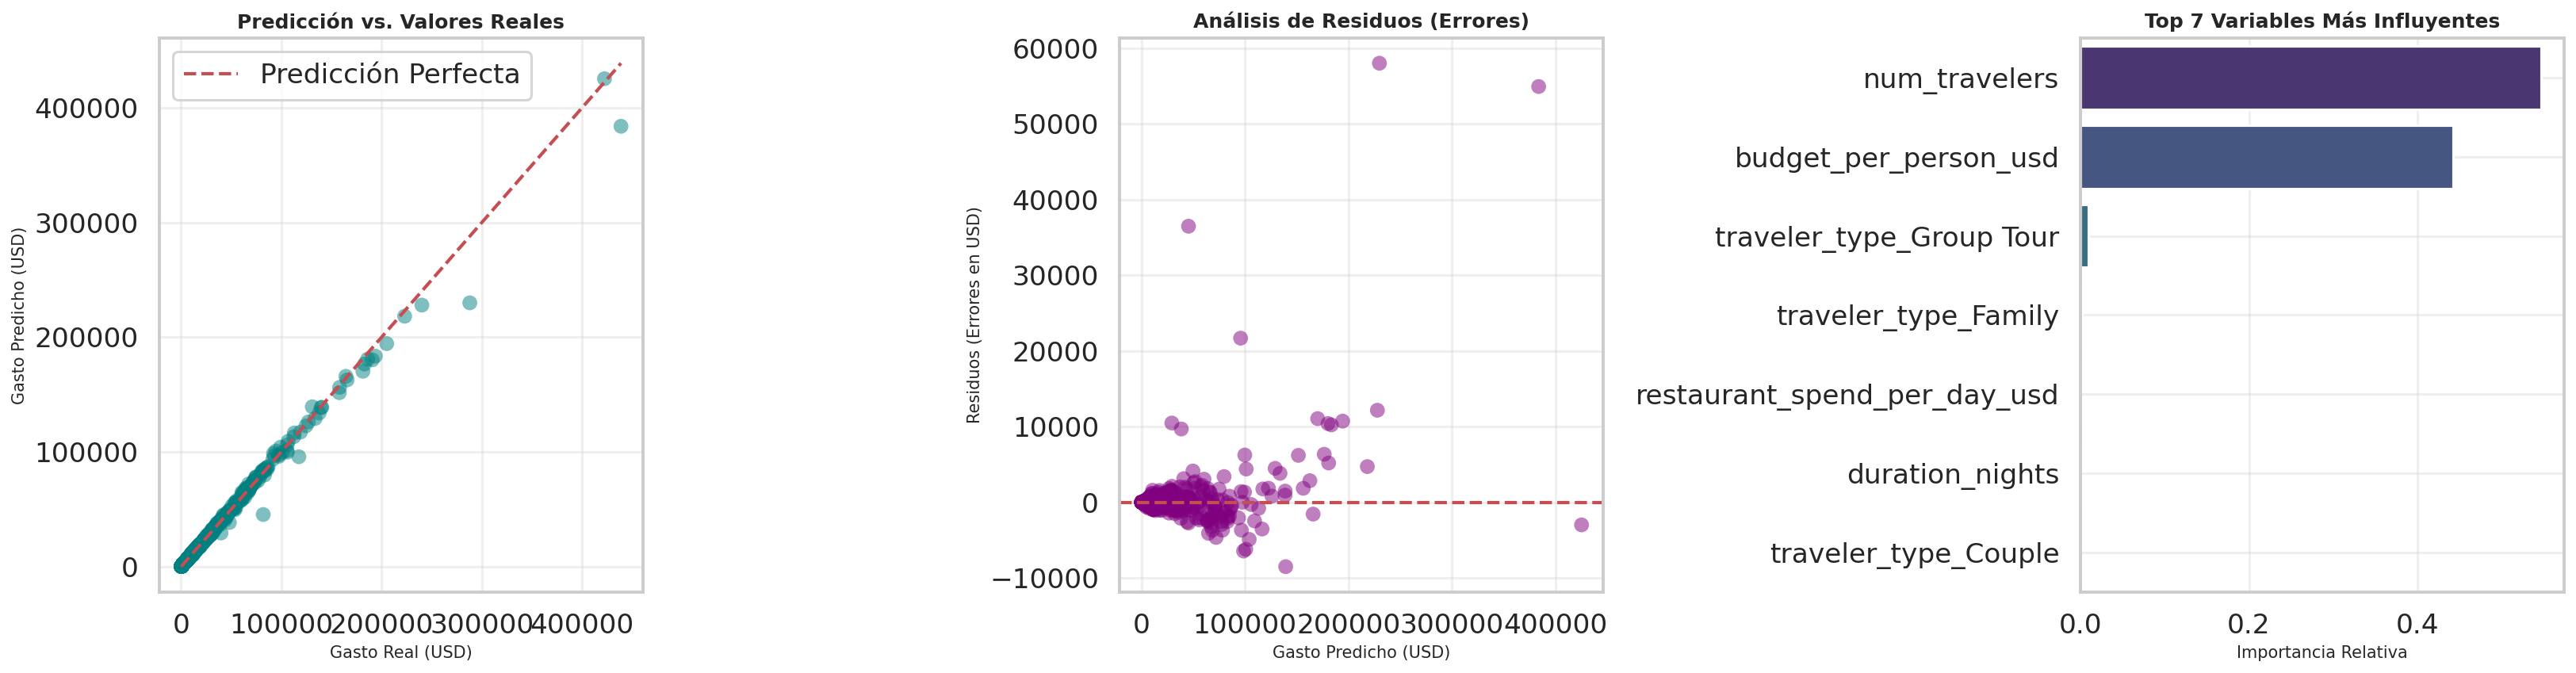

Tablero gráfico exportado con éxito como 'reporte_evaluacion_final.png'


In [ ]:
# =====================================================================
# CONTROL DE OVERFITTING Y TABLERO GRÁFICO
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("CONTROL DE OVERFITTING (ENTRENAMIENTO VS PRUEBA)")
print("=" * 70)

# Calculamos predicciones para ambos sets
y_pred_train = pipe_best.predict(X_train)
y_pred_test = pipe_best.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"• R² en el set de Entrenamiento (Train): {r2_train:.4f}")
print(f"• R² en el set de Validación (Test):     {r2_test:.4f}")
print(f"• Brecha de Overfitting:                  {abs(r2_train - r2_test):.4f}")

if abs(r2_train - r2_test) < 0.05:
    print("CONCLUSIÓN: El modelo generaliza de forma excelente. No hay indicios de Overfitting.")
else:
    print("ALERTA: Existe una brecha considerable. El modelo podría estar ligeramente sobreajustado.")
print("-" * 70 + "\n")


print("EXTRACCIÓN DE MÉTRICAS COMPLEMENTARIAS")
print("=" * 70)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"• Error Absoluto Medio Final (MAE):  ${mae_test:,.2f} USD")
print(f"• Raíz del Error Cuadrático (RMSE):   ${rmse_test:,.2f} USD")
print("-" * 70 + "\n")


print("GENERACIÓN DEL TABLERO GRÁFICO DE AUDITORÍA")
print("=" * 70)

# Creamos un lienzo multíple (1 fila, 3 columnas) para maquetar el reporte visual
fig, axes = plt.subplots(1, 3, figsize=(22, 6), dpi=150)

# GRÁFICA A: PREDICCIÓN VS REALIDAD
axes[0].scatter(y_test, y_pred_test, color='teal', alpha=0.5, edgecolor='none')

# Línea de referencia de predicción perfecta (45 grados)
lims = [0, max(max(y_test), max(y_pred_test))]
axes[0].plot(lims, lims, 'r--', lw=2, label='Predicción Perfecta')
axes[0].set_xlabel('Gasto Real (USD)', fontsize=10)
axes[0].set_ylabel('Gasto Predicho (USD)', fontsize=10)
axes[0].set_title('Predicción vs. Valores Reales', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# GRÁFICA B: ANÁLISIS DE RESIDUOS
residuos = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuos, color='purple', alpha=0.5, edgecolor='none')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Gasto Predicho (USD)', fontsize=10)
axes[1].set_ylabel('Residuos (Errores en USD)', fontsize=10)
axes[1].set_title('Análisis de Residuos (Errores)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# GRÁFICA C: FEATURE IMPORTANCE (IMPORTANCIA DE VARIABLES)

# Extraemos las importancias directamente del regresor dentro del Pipeline
importancias = pipe_best.named_steps['regressor'].regressor_.feature_importances_
df_importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False).head(7) # Mostramos las 7 principales para no saturar

sns.barplot(x='Importancia', y='Variable', data=df_importancias, ax=axes[2], palette='viridis', hue='Variable', legend=False)
axes[2].set_xlabel('Importancia Relativa', fontsize=10)
axes[2].set_ylabel('', fontsize=10)
axes[2].set_title('Top 7 Variables Más Influyentes', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("assets/reporte_evaluacion_final.png", bbox_inches='tight')
plt.show()

print("Tablero gráfico exportado con éxito como 'reporte_evaluacion_final.png'")
print("=" * 70)

## FASE 7 - Exportación del Modelo y Metadata

En la etapa de cierre, los artefactos generados son serializados para permitir su despliegue en entornos de producción.

### Acciones realizadas:
1. **Serialización del Pipeline:** Guardado del objeto `pipe_best` mediante `joblib` o `pickle` para su reutilización.
2. **Documentación de Metadatos:** Generación de un archivo `.json` que contiene las características requeridas por el modelo y la versión del mismo, garantizando la trazabilidad total del proyecto.

In [ ]:
df_final.to_csv("data/dataset_viajes_procesado.csv", index=False)

In [ ]:
# =====================================================================
# EXPORTACIÓN DEL MODELO Y METADATA
# =====================================================================
import joblib
import json
import os

print("INICIANDO EXPORTACIÓN OFICIAL - FASE 13")
print("=" * 70)

# ---------------------------------------------------------------------
# EXPORTACIÓN: El Pipeline Completo (.pkl)
# ---------------------------------------------------------------------
nombre_pipeline = "modelo_turismo.pkl"

# Guardamos el pipeline completo (StandardScaler + GradientBoosting)
joblib.dump(pipe_best, nombre_pipeline)
print(f"PIPELINE EXPORTADO: '{nombre_pipeline}'")


# ---------------------------------------------------------------------
# EXPORTACIÓN: Los Metadatos del Modelo (.json)
# ---------------------------------------------------------------------
nombre_metadata = "modelo_metadata.json"

# Estructuramos el diccionario con la información exacta solicitada
metadata = {
    "features_esperadas": list(X_train.columns),
    "mejores_hiperparametros": best_params,
    "metricas_finales": {
        "R2_Train": float(r2_train),
        "R2_Test": float(r2_test),
        "MAE_USD": float(mae_final),
        "RMSE_USD": float(rmse_final)
    }
}

# Guardamos el archivo JSON de forma legible (con sangría/indent)
with open(nombre_metadata, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print(f"METADATA EXPORTADA: '{nombre_metadata}'")
print("-" * 70)


# ---------------------------------------------------------------------
# VERIFICACIÓN DE ALMACENAMIENTO EN DISCO
# ---------------------------------------------------------------------
for archivo in [nombre_pipeline, nombre_metadata]:
    if os.path.exists(archivo):
        peso_mb = os.path.getsize(archivo) / (1024 * 1024)
        print(f"Confirmado: {archivo} | Tamaño: {peso_mb:.4f} MB")
    else:
        print(f"ERROR: No se encuentra el archivo {archivo}")
print("=" * 70)
print("¡Fase finalizada con éxito!")

INICIANDO EXPORTACIÓN OFICIAL - FASE 13
PIPELINE EXPORTADO: 'modelo_turismo.pkl'
METADATA EXPORTADA: 'modelo_metadata.json'
----------------------------------------------------------------------
Confirmado: modelo_turismo.pkl | Tamaño: 0.6155 MB
Confirmado: modelo_metadata.json | Tamaño: 0.0015 MB
¡Fase finalizada con éxito!


## Conclusiones Finales

El desarrollo metodológico consolidado en este proyecto ha permitido transformar una base de datos de tendencias turísticas transaccionales en un **sistema predictivo de alto rendimiento**. A través de las fases ejecutadas, nuestro grupo ha logrado alcanzar hitos clave:

1. **Saneamiento y Calidad de Datos:** La implementación de procesos de normalización de textos, limpieza de *outliers* mediante $IQR$ y mapeo de variables ordinales ha garantizado que el modelo trabaje sobre datos íntegros y coherentes, eliminando sesgos tipográficos y numéricos.
2. **Inteligencia Analítica y Multivariante:** El EDA realizado, que integra inferencia estadística (T-Test) y análisis visual multivariado, ha permitido validar que factores como el propósito del viaje, el destino y la sostenibilidad son predictores determinantes del gasto final.
3. **Optimización de Precisión:** La transición desde un modelo base de Árbol de Decisión hacia un ensamble optimizado mediante **Gradient Boosting y validación Bayesiana (Optuna)** ha permitido maximizar el coeficiente de determinación ($R^2$), logrando una capacidad predictiva robusta con un control estricto sobre el *overfitting*.
4. **Viabilidad Operativa:** La construcción final de un `Pipeline` serializado, listo para entornos de producción y capaz de realizar inferencias en tiempo real, demuestra que la solución no solo es teóricamente sólida, sino prácticamente aplicable para la toma de decisiones comerciales en la industria turística.

*En síntesis, este proyecto constituye un activo estratégico que permite anticipar el comportamiento financiero del cliente final, optimizando la capacidad de cotización y planificación de servicios turísticos basados en datos.*